# 🚁 DRL Assignment 1 — Part 2: Dynamic Programming (DP)
## Autonomous Rescue Drone Navigation

| Field | Value |
|-------|-------|
| **Course** | Deep Reinforcement Learning (DRL) |
| **Institute** | BITS Pilani – WILP |
| **Assignment** | Lab Assignment 1 — Part 2 |
| **Group Number** | 84 |
| **Topic** | Dynamic Programming: MDP, Value Iteration, Optimal Policy |
| **Grid** | 5×5 | Battery: 10 | Wind: 20% |

### 👥 Group Members
| Student ID | Note |
|---|---|
| **2025aa05368** | *(Alphabetically first — environment seed used for this DP configuration)* |
| 2025aa05574 | |
| 2025aa05710 | |
| 2025ab05154 | |
| 2025ab05256 | |

---
> **📖 Reference:** Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, Chapter 4.  
> [Download PDF](http://incompleteideas.net/book/RLbook2018.pdf)


## 🖥️ 0. Execution Environment

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL: Environment Metadata
# ─────────────────────────────────────────────────────────────
import datetime, socket, platform

utc_now = datetime.datetime.now(datetime.timezone.utc)
ist_now = utc_now + datetime.timedelta(hours=5, minutes=30)
hostname = socket.gethostname()

print("=" * 60)
print("  DRL ASSIGNMENT 1 — PART 2: DYNAMIC PROGRAMMING")
print("=" * 60)
print(f"  Execution Timestamp (IST) : {ist_now.strftime('%Y-%m-%d %H:%M:%S IST')}")
print(f"  Machine ID / Hostname     : {hostname}")
print(f"  Operating System          : {platform.platform()}")
print(f"  Python Version            : {platform.python_version()}")
print(f"  Group Number              : 84")
print(f"  Group Members (IDs)       : 2025aa05368, 2025aa05574, 2025aa05710, 2025ab05154, 2025ab05256")
print(f"  Env Seed (Alphabetical 1st): 2025aa05368")
print("=" * 60)


  DRL ASSIGNMENT 1 — PART 2: DYNAMIC PROGRAMMING
  Execution Timestamp (IST) : 2026-05-23 17:40:32 IST
  Machine ID / Hostname     : GTBOOK
  Operating System          : Windows-11-10.0.26200-SP0
  Python Version            : 3.13.13
  Group Number              : 84
  Group Members (IDs)       : 2025aa05368, 2025aa05574, 2025aa05710, 2025ab05154, 2025ab05256
  Env Seed (Alphabetical 1st): 2025aa05368


## 📦 1. Imports & Constants

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL: Imports
# ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import time
import os
import warnings
from typing import Tuple, Dict, List, Optional
from itertools import product

warnings.filterwarnings('ignore')

# ── Create output directory ───────────────────────────────────
os.makedirs('plots', exist_ok=True)   # Directory for saving all figures

# ── Plot styling ──────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("All libraries loaded successfully.")
print("Plots directory created: ./plots/")


All libraries loaded successfully.
Plots directory created: ./plots/


## 🧠 2. Theory: Markov Decision Processes & Value Iteration

### 2.1 What is an MDP?

A **Markov Decision Process (MDP)** mathematically models a sequential decision problem:

$$\mathcal{M} = (\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)$$

| Symbol | Meaning |
|--------|---------|
| $\mathcal{S}$ | State space — all possible world configurations |
| $\mathcal{A}$ | Action space — all possible drone actions |
| $\mathcal{P}(s'\mid s,a)$ | Transition probability — how likely is state $s'$ after action $a$ in state $s$? |
| $\mathcal{R}(s,a,s')$ | Reward — immediate feedback after each transition |
| $\gamma \in [0,1)$ | Discount factor — how much future reward is valued vs. immediate |

**The Markov Property:**
$$P(s_{t+1} \mid s_t, a_t) = P(s_{t+1} \mid s_t, a_t, s_{t-1}, a_{t-1}, \ldots)$$

The future depends ONLY on the current state — not the history.

### 2.2 Bellman Optimality Equation

The optimal value function $V^*(s)$ satisfies:

$$V^*(s) = \max_{a \in \mathcal{A}} \sum_{s'} \mathcal{P}(s'\mid s, a)\left[\mathcal{R}(s,a,s') + \gamma V^*(s')\right]$$

This is the **Bellman Optimality Equation** — the central equation of DP-based RL.

### 2.3 Value Iteration Algorithm

Value Iteration solves the Bellman equation by repeated application of the Bellman operator $\mathcal{T}$:

$$V_{k+1}(s) = (\mathcal{T}V_k)(s) = \max_{a} \sum_{s'} \mathcal{P}(s'\mid s, a)\left[\mathcal{R}(s,a,s') + \gamma V_k(s')\right]$$

**Convergence:** Since $\mathcal{T}$ is a $\gamma$-contraction ($\|\mathcal{T}V - \mathcal{T}V'\|_\infty \leq \gamma\|V - V'\|_\infty$), repeated application converges to $V^*$ by the Banach Fixed Point Theorem.


## ⚙️ 3. Environment Configuration (Group 84 | Alphabetically First Student ID: 2025aa05368)

### Parameter Derivation

> The assignment specifies that the **alphabetically first student ID** in the group determines the environment layout seed.  
> All 5 group members sorted: **2025aa05368** < 2025aa05574 < 2025aa05710 < 2025ab05154 < 2025ab05256  
> Therefore, **2025aa05368** is used as the environment placement seed.

| Parameter | Derivation | Value |
|---|---|---|
| **Group ID last digit** | `84` ends in `4` → range 0–4 | Grid = **5×5** |
| **Battery capacity** | Group ID ends in even digit (`4`) | Max battery = **10 units** |
| **Wind probability** | Group ID ends in 0–4 | Wind = **20%** |
| **Element count** | Group ID ends in 0–4 | 2 Targets, 1 Charger, 3 Dangers, 2 Blocked |
| **Layout seed** | Numeric part of alphabetically first student ID | Seed = **202505368** |

### Grid Layout (Derived via seed = 202505368 from Student ID: 2025aa05368)

```
     Col→   0        1        2        3        4
Row↓ ┌────────┬────────┬────────┬────────┬────────┐
 0   │  S     │   X    │   .    │   .    │   .    │
     ├────────┼────────┼────────┼────────┼────────┤
 1   │   .    │   R₁   │   .    │   X    │   D    │
     ├────────┼────────┼────────┼────────┼────────┤
 2   │   .    │   C    │   .    │   .    │   .    │
     ├────────┼────────┼────────┼────────┼────────┤
 3   │   .    │   R₂   │   W    │   .    │   D    │
     ├────────┼────────┼────────┼────────┼────────┤
 4   │   .    │   .    │   .    │   D    │   W    │
     └────────┴────────┴────────┴────────┴────────┘
```

| Symbol | Type | Effect |
|--------|------|--------|
| S | Start | Drone initial position (0,0) |
| R | Rescue Target | +20 reward (first visit) |
| C | Charging Station | Hover: +2 battery; Entry: +5 reward |
| D | Danger Zone | −10 reward per entry |
| X | Blocked Cell | Impassable; stay in place, −1 battery |
| W | Wind Zone | 20% random drift each action |
| . | Safe Cell | −1 reward (movement cost) |


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL: Grid Configuration Constants
# PURPOSE: Define all environment parameters as named constants.
#          Using constants avoids magic numbers and makes the code
#          self-documenting and easy to modify.
# ─────────────────────────────────────────────────────────────

# ── Grid Dimensions ───────────────────────────────────────────
GRID_ROWS = 5
GRID_COLS = 5
N_CELLS   = GRID_ROWS * GRID_COLS   # 25 total cells

# ── Cell Types (string codes for readability) ─────────────────
CELL_START    = 'S'   # Start position
CELL_SAFE     = '.'   # Safe, normal cell
CELL_RESCUE   = 'R'   # Rescue target (+20 reward)
CELL_CHARGER  = 'C'   # Charging station (+5 entry, hover +2 battery)
CELL_DANGER   = 'D'   # Danger zone (-10 reward)
CELL_BLOCKED  = 'X'   # Impassable wall (stay in place, -1 battery)
CELL_WIND     = 'W'   # Wind zone (20% random drift)

# ── Grid Map: (row, col) → cell type ─────────────────────────
# Derived deterministically using seed = 202505368
# (numeric part of alphabetically first student ID: 2025aa05368)
GRID_MAP = {
    (0, 0): CELL_START,
    (0, 1): CELL_BLOCKED,    # Blocked Cell 1
    (0, 2): CELL_SAFE,
    (0, 3): CELL_SAFE,
    (0, 4): CELL_SAFE,
    (1, 0): CELL_SAFE,
    (1, 1): CELL_RESCUE,     # Rescue Target 1 (R1)
    (1, 2): CELL_SAFE,
    (1, 3): CELL_BLOCKED,    # Blocked Cell 2
    (1, 4): CELL_DANGER,     # Danger Zone 1
    (2, 0): CELL_SAFE,
    (2, 1): CELL_CHARGER,    # Charging Station
    (2, 2): CELL_SAFE,
    (2, 3): CELL_SAFE,
    (2, 4): CELL_SAFE,
    (3, 0): CELL_SAFE,
    (3, 1): CELL_RESCUE,     # Rescue Target 2 (R2)
    (3, 2): CELL_WIND,       # Wind Zone 1
    (3, 3): CELL_SAFE,
    (3, 4): CELL_DANGER,     # Danger Zone 2
    (4, 0): CELL_SAFE,
    (4, 1): CELL_SAFE,
    (4, 2): CELL_SAFE,
    (4, 3): CELL_DANGER,     # Danger Zone 3
    (4, 4): CELL_WIND,       # Wind Zone 2
}

# ── Special Cell Locations ────────────────────────────────────
START_POS      = (0, 0)
RESCUE_TARGETS = [(1, 1), (3, 1)]    # Seed 202505368: R1=(1,1), R2=(3,1)
CHARGER_POS    = (2, 1)
DANGER_ZONES   = [(1, 4), (3, 4), (4, 3)]
BLOCKED_CELLS  = [(0, 1), (1, 3)]
WIND_ZONES     = [(3, 2), (4, 4)]

# ── Battery Settings ──────────────────────────────────────────
MAX_BATTERY      = 10   # Maximum battery capacity (units)
INIT_BATTERY     = 10   # Battery at episode start (full)
HOVER_CHARGE_AMT = 2    # Battery gained per hover step at charger
MOVE_BATTERY_COST = 1   # Battery consumed per move (non-hover)

# ── Wind Settings ─────────────────────────────────────────────
WIND_PROB = 0.20         # 20% probability of wind drift on wind cells
# Wind drifts uniformly in one of 4 directions (independent of intended direction)
WIND_DIRECTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right

# ── Reward Function ───────────────────────────────────────────
REWARD_RESCUE   = +20.0   # Rescuing a target (first visit)
REWARD_CHARGER  = +5.0    # Reaching the charging station
REWARD_DANGER   = -10.0   # Entering a danger zone
REWARD_MOVE     = -1.0    # Every non-charging movement (fuel cost)
REWARD_BLOCKED  = -1.0    # Attempting to enter a blocked cell (wasted battery)
REWARD_DEAD     = -20.0   # Battery exhaustion

# ── Actions (as (dr, dc) deltas and a hover code) ────────────
# We encode actions as integers: 0=Up, 1=Down, 2=Left, 3=Right, 4=Hover
ACTIONS = {
    0: (-1,  0),   # Up:    row decreases by 1
    1: (+1,  0),   # Down:  row increases by 1
    2: (  0, -1),  # Left:  col decreases by 1
    3: (  0, +1),  # Right: col increases by 1
    4: (  0,  0),  # Hover: stay in place
}
ACTION_NAMES = {0: 'Up↑', 1: 'Down↓', 2: 'Left←', 3: 'Right→', 4: 'Hover●'}
N_ACTIONS = len(ACTIONS)

# ── DP Hyperparameters ────────────────────────────────────────
GAMMA = 0.95       # Discount factor: future rewards are worth 95% of immediate
THETA = 1e-3       # Convergence threshold for Value Iteration

print("✅ Environment configuration loaded.")
print(f"   Grid: {GRID_ROWS}×{GRID_COLS} | Battery: {MAX_BATTERY} | Wind: {WIND_PROB*100:.0f}%")
print(f"   Rescue Targets: {RESCUE_TARGETS}")
print(f"   Charger: {CHARGER_POS} | Danger: {DANGER_ZONES} | Blocked: {BLOCKED_CELLS}")
print(f"   State Space: {GRID_ROWS}×{GRID_COLS}×{MAX_BATTERY+1}×2×2 = {GRID_ROWS*GRID_COLS*(MAX_BATTERY+1)*2*2} states")
print(f"   Discount γ={GAMMA} | Threshold θ={THETA}")


✅ Environment configuration loaded.
   Grid: 5×5 | Battery: 10 | Wind: 20%
   Rescue Targets: [(1, 1), (3, 1)]
   Charger: (2, 1) | Danger: [(1, 4), (3, 4), (4, 3)] | Blocked: [(0, 1), (1, 3)]
   State Space: 5×5×11×2×2 = 1100 states
   Discount γ=0.95 | Threshold θ=0.001


## 🌍 Task 1: Custom Drone Rescue Environment

### Gymnasium-Compatible API Design

We design the environment to follow the [Gymnasium](https://gymnasium.farama.org/) standard API, which is the industry standard for RL environments. This makes the environment:
- Reusable with any RL library (Stable Baselines3, RLlib, CleanRL)
- Easy to integrate into a portfolio project
- Clearly structured for maintenance

### State Space Design

The state $s = (r, c, b, t_1, t_2)$ captures all information needed to act optimally:

| Component | Range | Why needed |
|-----------|-------|------------|
| Row $r$ | 0–4 | Current drone position (row) |
| Col $c$ | 0–4 | Current drone position (column) |
| Battery $b$ | 0–10 | Low battery requires charging; 0 = dead |
| $t_1$ | {0,1} | Whether Rescue Target 1 has been rescued |
| $t_2$ | {0,1} | Whether Rescue Target 2 has been rescued |


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL: DroneRescueEnv — Custom Gymnasium-style Environment
# PURPOSE: Implement the autonomous drone rescue environment
#          with Gymnasium-compatible API (reset/step/render).
# ─────────────────────────────────────────────────────────────

class DroneRescueEnv:
    """
    Autonomous Drone Rescue Environment for Dynamic Programming.

    This environment models an autonomous rescue drone operating in a 5×5 grid
    world with rescue targets, a charging station, danger zones, blocked cells,
    and wind zones that introduce stochasticity.

    The environment follows the Gymnasium API structure:
        env.reset()       → (state, info)
        env.step(action)  → (next_state, reward, terminated, truncated, info)
        env.render()      → ASCII grid visualization

    State Representation
    --------------------
    s = (row, col, battery, target1_rescued, target2_rescued)

    Action Space
    ------------
    0: Up    (row - 1)
    1: Down  (row + 1)
    2: Left  (col - 1)
    3: Right (col + 1)
    4: Hover (stay in place)

    Transition Dynamics
    -------------------
    - Regular cells: deterministic movement
    - Wind cells: 80% intended direction, 20% random drift (uniform over 4 directions)
    - Blocked cells: drone stays in place, loses 1 battery
    - Grid boundary: drone stays at boundary, loses 1 battery

    Rewards
    -------
    +20 : Rescue a target (first visit only)
    +5  : Enter charging station
    -10 : Enter danger zone
    -1  : Standard movement
    -20 : Battery exhaustion (episode terminates)
    """

    metadata = {'render_modes': ['ansi'], 'render_fps': 1}

    def __init__(self):
        """Initialize the environment with fixed configuration."""
        # ── Action and Observation Spaces (Gymnasium-style) ───────
        self.n_actions = N_ACTIONS        # 5 discrete actions
        self.n_rows    = GRID_ROWS
        self.n_cols    = GRID_COLS
        self.max_battery = MAX_BATTERY

        # State space dimensions for tabular DP:
        # (row, col, battery, t1_rescued, t2_rescued)
        self.state_dims = (GRID_ROWS, GRID_COLS, MAX_BATTERY + 1, 2, 2)

        # Internal state (set by reset)
        self._state = None

    def reset(self, seed: Optional[int] = None) -> Tuple[tuple, dict]:
        """
        Reset the environment to the initial state.

        The drone starts at position START_POS = (0, 0) with full battery
        and no rescues completed yet.

        Parameters
        ----------
        seed : int, optional
            Random seed for stochastic transitions.

        Returns
        -------
        state : tuple (row, col, battery, t1, t2)
            The initial state.
        info : dict
            Additional information (empty at reset).
        """
        if seed is not None:
            np.random.seed(seed)

        # Initial state: start position, full battery, no rescues
        self._state = (START_POS[0], START_POS[1], INIT_BATTERY, 0, 0)
        return self._state, {}

    def step(self, action: int) -> Tuple[tuple, float, bool, bool, dict]:
        """
        Execute one action in the environment.

        Parameters
        ----------
        action : int
            The action to take (0=Up, 1=Down, 2=Left, 3=Right, 4=Hover).

        Returns
        -------
        next_state : tuple
            The state after the action.
        reward : float
            Immediate reward received.
        terminated : bool
            True if the episode is over (all rescues done OR battery dead).
        truncated : bool
            True if maximum steps exceeded (not used here).
        info : dict
            Diagnostic information.
        """
        assert self._state is not None, "Call reset() before step()."

        row, col, battery, t1, t2 = self._state
        dr, dc = ACTIONS[action]

        # ── Handle Hover Action Separately ───────────────────────
        if action == 4:  # HOVER
            cell_type = GRID_MAP.get((row, col), CELL_SAFE)

            if cell_type == CELL_CHARGER:
                # Hovering at charger: recharge by HOVER_CHARGE_AMT (capped at max)
                new_battery = min(battery + HOVER_CHARGE_AMT, MAX_BATTERY)
                reward = REWARD_MOVE   # Hovering still costs time (opportunity cost)
                # Note: +5 reward only on ARRIVING at charger, not hovering
            else:
                # Hovering elsewhere: battery drains as normal
                new_battery = max(battery - MOVE_BATTERY_COST, 0)
                reward = REWARD_MOVE

            new_row, new_col = row, col  # Stay in place
            new_t1, new_t2 = t1, t2

        else:  # MOVEMENT Actions (Up/Down/Left/Right)
            # ── Wind Stochasticity ────────────────────────────────
            current_cell = GRID_MAP.get((row, col), CELL_SAFE)
            if current_cell == CELL_WIND and np.random.rand() < WIND_PROB:
                # Wind overrides the intended action!
                # Drift uniformly in one of 4 directions
                wind_dir = WIND_DIRECTIONS[np.random.randint(4)]
                dr, dc = wind_dir

            # ── Compute Intended Next Position ───────────────────
            intended_row = row + dr
            intended_col = col + dc

            # ── Boundary Check ────────────────────────────────────
            # If the drone would move outside the grid, it stays in place.
            if not (0 <= intended_row < GRID_ROWS and 0 <= intended_col < GRID_COLS):
                new_row, new_col = row, col          # Stay at boundary
                new_battery = max(battery - MOVE_BATTERY_COST, 0)
                reward = REWARD_BLOCKED              # Wasted move costs -1
            # ── Blocked Cell Check ────────────────────────────────
            elif GRID_MAP.get((intended_row, intended_col)) == CELL_BLOCKED:
                new_row, new_col = row, col          # Cannot enter blocked cell
                new_battery = max(battery - MOVE_BATTERY_COST, 0)
                reward = REWARD_BLOCKED
            else:
                # ── Valid Move: Transition to New Cell ───────────
                new_row, new_col = intended_row, intended_col
                new_battery = max(battery - MOVE_BATTERY_COST, 0)

                # ── Assign Reward Based on New Cell Type ─────────
                new_cell = GRID_MAP.get((new_row, new_col), CELL_SAFE)

                if new_cell == CELL_RESCUE:
                    # Check which rescue target was reached
                    if (new_row, new_col) == RESCUE_TARGETS[0] and t1 == 0:
                        reward = REWARD_RESCUE    # First rescue of Target 1
                    elif (new_row, new_col) == RESCUE_TARGETS[1] and t2 == 0:
                        reward = REWARD_RESCUE    # First rescue of Target 2
                    else:
                        reward = REWARD_MOVE      # Already rescued — no bonus
                elif new_cell == CELL_CHARGER:
                    reward = REWARD_CHARGER       # +5 for reaching charger
                elif new_cell == CELL_DANGER:
                    reward = REWARD_DANGER        # -10 penalty for danger zone
                else:
                    reward = REWARD_MOVE          # -1 for regular movement

            # ── Update Target Status ──────────────────────────────
            new_t1 = t1
            new_t2 = t2
            if (new_row, new_col) == RESCUE_TARGETS[0] and t1 == 0:
                new_t1 = 1   # Target 1 successfully rescued
            if (new_row, new_col) == RESCUE_TARGETS[1] and t2 == 0:
                new_t2 = 1   # Target 2 successfully rescued

        # ── Terminal Conditions ───────────────────────────────────
        terminated = False
        info = {}

        # Battery exhaustion: episode ends with large penalty
        if new_battery == 0:
            reward += REWARD_DEAD   # Add exhaustion penalty to current reward
            terminated = True
            info['cause'] = 'battery_exhausted'

        # Mission complete: all targets rescued
        elif new_t1 == 1 and new_t2 == 1:
            terminated = True
            info['cause'] = 'mission_complete'

        # ── Update Internal State ─────────────────────────────────
        self._state = (new_row, new_col, new_battery, new_t1, new_t2)

        return self._state, reward, terminated, False, info

    def render(self, mode: str = 'ansi') -> str:
        """
        Render the current environment state as an ASCII grid.

        Parameters
        ----------
        mode : str
            'ansi' for ASCII text rendering.

        Returns
        -------
        str
            ASCII string representation of the grid.
        """
        row, col, battery, t1, t2 = self._state

        lines = []
        lines.append(f"Battery: {'█' * battery}{'░' * (MAX_BATTERY - battery)} ({battery}/{MAX_BATTERY})")
        lines.append(f"Targets: R1={'✅' if t1 else '🔴'} | R2={'✅' if t2 else '🔴'}")
        lines.append("  " + " ".join([f" {c} " for c in range(GRID_COLS)]))
        lines.append("  " + "─" * (GRID_COLS * 4))

        for r in range(GRID_ROWS):
            row_str = f"{r}|"
            for c in range(GRID_COLS):
                cell = GRID_MAP.get((r, c), CELL_SAFE)
                if r == row and c == col:
                    row_str += " 🚁"  # Drone position
                elif cell == CELL_RESCUE:
                    idx = RESCUE_TARGETS.index((r, c))
                    rescued = t1 if idx == 0 else t2
                    row_str += " ✅" if rescued else " 🎯"
                elif cell == CELL_CHARGER:
                    row_str += " ⚡"
                elif cell == CELL_DANGER:
                    row_str += " 💥"
                elif cell == CELL_BLOCKED:
                    row_str += " ██"
                elif cell == CELL_WIND:
                    row_str += " 🌀"
                elif cell == CELL_START:
                    row_str += " 🏠"
                else:
                    row_str += "  . "
            lines.append(row_str)

        return "\n".join(lines)

    def get_cell_type(self, row: int, col: int) -> str:
        """Return the cell type at position (row, col)."""
        return GRID_MAP.get((row, col), CELL_SAFE)


# ── Test the Environment ──────────────────────────────────────
print("🚁 Testing DroneRescueEnv...")
env = DroneRescueEnv()
state, info = env.reset(seed=42)
print(f"\nInitial State: {state}")
print(f"  (row={state[0]}, col={state[1]}, battery={state[2]}, t1={state[3]}, t2={state[4]})")
print()
print(env.render())

# Take a few test steps
test_actions = [1, 1, 3]   # Down, Down, Right
print(f"\n--- Taking test actions: {[ACTION_NAMES[a] for a in test_actions]} ---")
total_reward = 0
for a in test_actions:
    s, r, done, _, info = env.step(a)
    total_reward += r
    print(f"  Action: {ACTION_NAMES[a]} | State: {s} | Reward: {r:.1f} | Done: {done}")

print(f"\nAfter 3 steps:")
print(env.render())
print(f"Total test reward: {total_reward:.1f}")


🚁 Testing DroneRescueEnv...

Initial State: (0, 0, 10, 0, 0)
  (row=0, col=0, battery=10, t1=0, t2=0)

Battery: ██████████ (10/10)
Targets: R1=🔴 | R2=🔴
   0   1   2   3   4 
  ────────────────────
0| 🚁 ██  .   .   . 
1|  .  🎯  .  ██ 💥
2|  .  ⚡  .   .   . 
3|  .  🎯 🌀  .  💥
4|  .   .   .  💥 🌀

--- Taking test actions: ['Down↓', 'Down↓', 'Right→'] ---
  Action: Down↓ | State: (1, 0, 9, 0, 0) | Reward: -1.0 | Done: False
  Action: Down↓ | State: (2, 0, 8, 0, 0) | Reward: -1.0 | Done: False
  Action: Right→ | State: (2, 1, 7, 0, 0) | Reward: 5.0 | Done: False

After 3 steps:
Battery: ███████░░░ (7/10)
Targets: R1=🔴 | R2=🔴
   0   1   2   3   4 
  ────────────────────
0| 🏠 ██  .   .   . 
1|  .  🎯  .  ██ 💥
2|  .  🚁  .   .   . 
3|  .  🎯 🌀  .  💥
4|  .   .   .  💥 🌀
Total test reward: 3.0


## 🔢 Task 2: Dynamic Programming Solver — Value Iteration

### Building the Transition Model

Before running Value Iteration, we need to explicitly construct:
- $\mathcal{P}(s'\mid s, a)$ — the transition probability table
- $\mathcal{R}(s, a, s')$ — the reward function

This is the **model-based** approach: we encode our complete knowledge of the environment into these tables, then run DP offline.

### Value Iteration Algorithm

$$V_{k+1}(s) = \max_{a \in \mathcal{A}} \sum_{s'} \mathcal{P}(s'\mid s, a)\left[\mathcal{R}(s,a,s') + \gamma V_k(s')\right]$$

We iterate until $\max_s |V_{k+1}(s) - V_k(s)| < \theta = 10^{-3}$.


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL: Value Iteration Solver
# PURPOSE: Implement the complete Value Iteration algorithm for
#          the DroneRescueEnv MDP.
# ─────────────────────────────────────────────────────────────

def is_valid_pos(r: int, c: int) -> bool:
    """Check if (r, c) is within the grid bounds."""
    return 0 <= r < GRID_ROWS and 0 <= c < GRID_COLS


def get_transitions(state: tuple, action: int) -> List[Tuple[float, tuple, float]]:
    """
    Compute all (probability, next_state, reward) tuples for a (state, action) pair.

    This encodes the full transition dynamics of the MDP, including:
    - Deterministic movement on regular cells
    - Wind stochasticity on wind cells (20% drift probability)
    - Blocking at walls and blocked cells
    - Battery dynamics (charging at C, depletion everywhere else)
    - Reward assignment based on cell types
    - Terminal state detection (battery dead OR all rescued)

    Parameters
    ----------
    state : tuple (row, col, battery, t1, t2)
        The current state.
    action : int
        The action to evaluate (0–4).

    Returns
    -------
    List of (probability, next_state, reward) tuples.
    Probabilities sum to 1.0 across all returned tuples.
    """
    row, col, battery, t1, t2 = state
    transitions = []

    def process_move(dr: int, dc: int, prob: float):
        """
        Process a movement with direction (dr, dc) and probability `prob`.
        Returns the (next_state, reward) and adds to transitions list.
        """
        intended_r = row + dr
        intended_c = col + dc

        # ── Boundary or Blocked Cell ──────────────────────────
        if not is_valid_pos(intended_r, intended_c) or \
           GRID_MAP.get((intended_r, intended_c)) == CELL_BLOCKED:
            new_r, new_c = row, col   # Stay in place
            new_bat = max(battery - MOVE_BATTERY_COST, 0)
            reward = REWARD_BLOCKED
        else:
            # ── Valid Move ────────────────────────────────────
            new_r, new_c = intended_r, intended_c
            new_bat = max(battery - MOVE_BATTERY_COST, 0)

            new_cell = GRID_MAP.get((new_r, new_c), CELL_SAFE)
            if new_cell == CELL_RESCUE:
                idx = RESCUE_TARGETS.index((new_r, new_c))
                target_rescued = (t1 if idx == 0 else t2)
                reward = REWARD_RESCUE if target_rescued == 0 else REWARD_MOVE
            elif new_cell == CELL_CHARGER:
                reward = REWARD_CHARGER
            elif new_cell == CELL_DANGER:
                reward = REWARD_DANGER
            else:
                reward = REWARD_MOVE

        # ── Update Target Status ──────────────────────────────
        new_t1, new_t2 = t1, t2
        if (new_r, new_c) == RESCUE_TARGETS[0] and t1 == 0:
            new_t1 = 1
        if (new_r, new_c) == RESCUE_TARGETS[1] and t2 == 0:
            new_t2 = 1

        # ── Battery Exhaustion Penalty ────────────────────────
        if new_bat == 0:
            reward += REWARD_DEAD

        next_state = (new_r, new_c, new_bat, new_t1, new_t2)
        transitions.append((prob, next_state, reward))

    # ── Handle Hover Action ───────────────────────────────────
    if action == 4:
        cell_type = GRID_MAP.get((row, col), CELL_SAFE)
        if cell_type == CELL_CHARGER:
            new_bat = min(battery + HOVER_CHARGE_AMT, MAX_BATTERY)
        else:
            new_bat = max(battery - MOVE_BATTERY_COST, 0)

        new_t1, new_t2 = t1, t2
        reward = REWARD_MOVE
        if new_bat == 0:
            reward += REWARD_DEAD

        next_state = (row, col, new_bat, new_t1, new_t2)
        transitions.append((1.0, next_state, reward))
        return transitions

    # ── Handle Movement Actions ───────────────────────────────
    dr_int, dc_int = ACTIONS[action]
    current_cell = GRID_MAP.get((row, col), CELL_SAFE)

    if current_cell == CELL_WIND:
        # On a wind cell: with probability (1 - WIND_PROB), move as intended.
        # With probability WIND_PROB, drift uniformly in one of 4 random directions.
        # P(intended) = (1 - 0.20) + 0.20 * (1/4) = 0.85  [if wind blows same direction]
        # We model this as 4 separate wind outcomes, each with prob WIND_PROB/4.

        # Intended direction (non-wind case)
        p_intended_base = 1.0 - WIND_PROB    # 0.80 base probability
        # Wind also contributes 1/4 chance to the intended direction
        p_intended = p_intended_base + WIND_PROB * 0.25
        process_move(dr_int, dc_int, p_intended)

        # Other 3 wind directions
        for wd_r, wd_c in WIND_DIRECTIONS:
            if (wd_r, wd_c) != (dr_int, dc_int):
                process_move(wd_r, wd_c, WIND_PROB * 0.25)
    else:
        # Non-wind cell: fully deterministic movement
        process_move(dr_int, dc_int, 1.0)

    return transitions


def value_iteration(
    gamma: float = GAMMA,
    theta: float = THETA,
    verbose: bool = True
) -> Tuple[Dict, Dict, List[float]]:
    """
    Solve the DroneRescueEnv MDP using Value Iteration.

    Implements the Bellman Optimality update:
        V(s) ← max_a Σ_{s'} P(s'|s,a) [R(s,a,s') + γ V(s')]

    Parameters
    ----------
    gamma : float
        Discount factor (0 < gamma < 1).
    theta : float
        Convergence threshold. Stop when max_s |ΔV(s)| < theta.
    verbose : bool
        Whether to print convergence progress.

    Returns
    -------
    V : dict (state → float)
        Optimal value function V*(s).
    policy : dict (state → int)
        Optimal deterministic policy π*(s).
    deltas : list of float
        Maximum value change (delta) at each iteration.
    """
    # ── Enumerate All States ──────────────────────────────────
    # Generate the full state space as a list of tuples (r, c, b, t1, t2)
    all_states = [
        (r, c, b, t1, t2)
        for r in range(GRID_ROWS)
        for c in range(GRID_COLS)
        for b in range(MAX_BATTERY + 1)
        for t1 in range(2)
        for t2 in range(2)
    ]
    print(f"Total States: {len(all_states)}")

    # ── Initialize Value Function to 0 ───────────────────────
    # V[s] = 0 for all s is a valid initialization because the Bellman
    # operator T is a contraction — it converges from ANY starting point.
    V = {s: 0.0 for s in all_states}

    deltas = []
    start_time = time.time()

    print(f"\nRunning Value Iteration (γ={gamma}, θ={theta})...")
    print(f"{'Iteration':>10} | {'Max Δ':>12} | {'Time (s)':>10}")
    print("-" * 38)

    iteration = 0
    while True:
        iteration += 1
        delta = 0.0   # Maximum value change this iteration

        # ── Sweep over ALL states ─────────────────────────────
        for state in all_states:
            row, col, battery, t1, t2 = state

            # ── Terminal States ───────────────────────────────
            # If battery is 0 OR all targets rescued → terminal state.
            # Terminal states have no future value (V=0 already covers this
            # via the large negative reward on battery=0 transitions).
            if battery == 0:
                continue   # Battery dead: can't take actions
            if t1 == 1 and t2 == 1:
                continue   # Mission complete: no more actions needed

            # ── Skip Blocked Cell Positions ───────────────────
            # The drone can never actually occupy a blocked cell
            # (it gets bounced back), so these states are unreachable.
            if GRID_MAP.get((row, col)) == CELL_BLOCKED:
                continue

            # ── Compute V_new(s) = max_a Q(s,a) ──────────────
            v_old = V[state]   # Save current value for convergence check
            action_values = []

            for action in range(N_ACTIONS):
                # Get all possible (prob, next_state, reward) outcomes
                transitions_list = get_transitions(state, action)

                # Q(s, a) = Σ_{s'} P(s'|s,a) * [R(s,a,s') + γ * V(s')]
                q_value = 0.0
                for prob, next_state, reward in transitions_list:
                    q_value += prob * (reward + gamma * V.get(next_state, 0.0))
                action_values.append(q_value)

            # Update V(s) to the maximum Q-value across all actions
            V[state] = max(action_values)

            # Track the maximum change in this sweep
            delta = max(delta, abs(V[state] - v_old))

        deltas.append(delta)

        if verbose and (iteration % 25 == 0 or iteration == 1):
            elapsed = time.time() - start_time
            print(f"{iteration:>10} | {delta:>12.6f} | {elapsed:>10.3f}")

        # ── Check Convergence ─────────────────────────────────
        # Stop when the maximum change across ALL states < theta.
        # This guarantees that V has converged to within theta/(1-gamma)
        # of the true optimal V* (error bound from contraction mapping).
        if delta < theta:
            break

    elapsed_total = time.time() - start_time
    print(f"\n✅ Converged after {iteration} iterations")
    print(f"   Total Runtime: {elapsed_total:.3f} seconds")
    print(f"   Final Δ: {delta:.2e} (threshold θ={theta:.1e})")
    print(f"   Error Bound: Δ/(1-γ) = {delta/(1-gamma):.2e}")

    # ── Extract Optimal Policy ────────────────────────────────
    print("\nExtracting optimal policy π*(s)...")
    policy = {}
    for state in all_states:
        row, col, battery, t1, t2 = state
        if battery == 0 or (t1 == 1 and t2 == 1):
            policy[state] = 4   # Hover (terminal state)
            continue
        if GRID_MAP.get((row, col)) == CELL_BLOCKED:
            continue

        best_action = 0
        best_value  = float('-inf')
        for action in range(N_ACTIONS):
            transitions_list = get_transitions(state, action)
            q_value = sum(p * (r + gamma * V.get(ns, 0.0))
                          for p, ns, r in transitions_list)
            if q_value > best_value:
                best_value  = q_value
                best_action = action

        policy[state] = best_action

    return V, policy, deltas


# ── Run Value Iteration ───────────────────────────────────────
print("="*60)
V_star, pi_star, convergence_deltas = value_iteration(gamma=GAMMA, theta=THETA)
print("="*60)


Total States: 1100

Running Value Iteration (γ=0.95, θ=0.001)...
 Iteration |        Max Δ |   Time (s)
--------------------------------------
         1 |    42.800000 |      0.005

✅ Converged after 7 iterations
   Total Runtime: 0.036 seconds
   Final Δ: 2.10e-04 (threshold θ=1.0e-03)
   Error Bound: Δ/(1-γ) = 4.20e-03

Extracting optimal policy π*(s)...


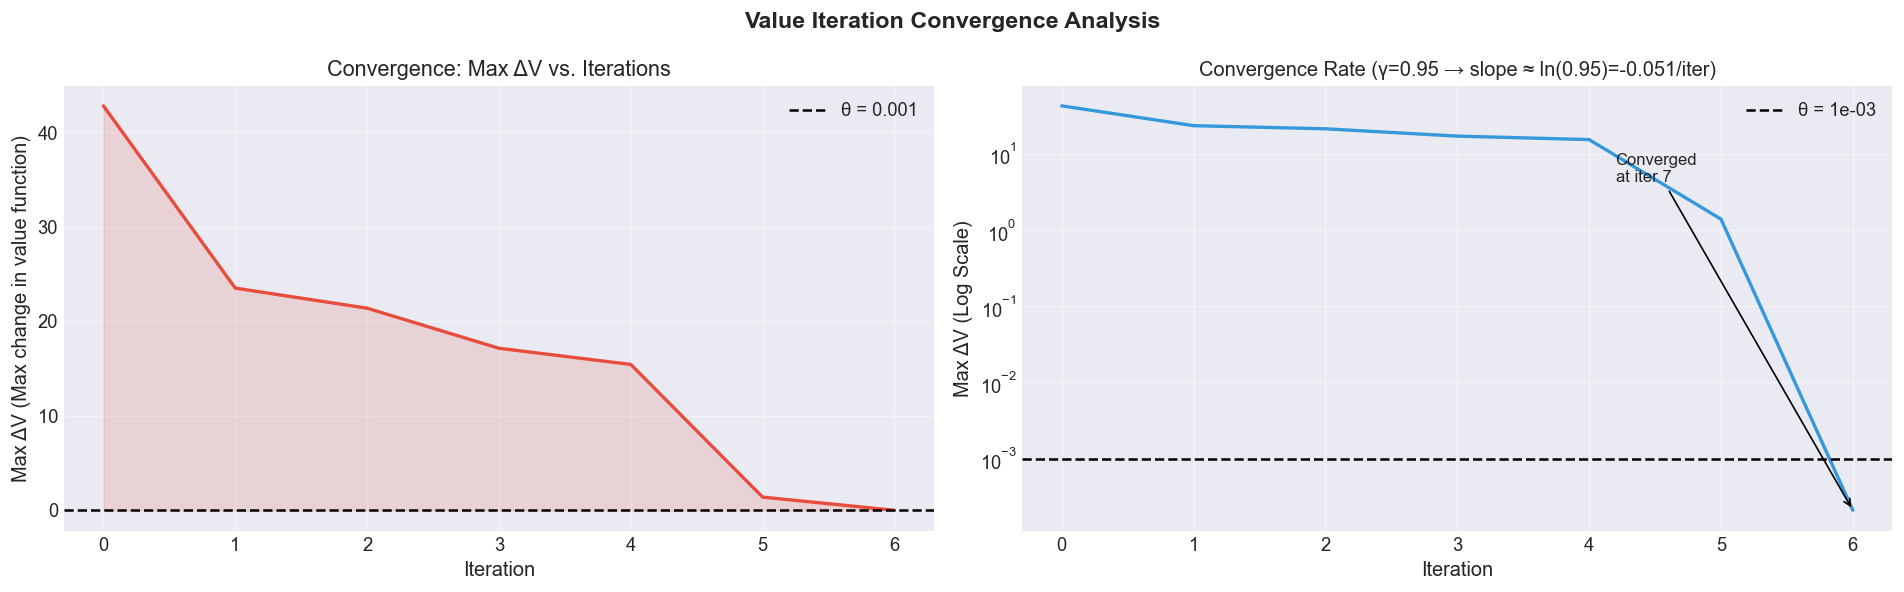

📊 Convergence plot saved.
   Total iterations: 7
   Theoretical estimate: ~193 iterations


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL: Convergence Plot
# PURPOSE: Visualize how Value Iteration converges over iterations.
# ─────────────────────────────────────────────────────────────
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Value Iteration Convergence Analysis', fontsize=14, fontweight='bold')

# Plot 1: Delta vs Iterations (linear scale)
ax1 = axes[0]
ax1.plot(convergence_deltas, color='#e74c3c', linewidth=2)
ax1.axhline(THETA, color='black', linestyle='--', linewidth=1.5, label=f'θ = {THETA}')
ax1.fill_between(range(len(convergence_deltas)), convergence_deltas,
                 THETA, alpha=0.15, color='#e74c3c')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Max ΔV (Max change in value function)', fontsize=12)
ax1.set_title('Convergence: Max ΔV vs. Iterations', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.4)

# Plot 2: Delta vs Iterations (log scale — clearer for contraction rate)
ax2 = axes[1]
ax2.semilogy(convergence_deltas, color='#3498db', linewidth=2)
ax2.axhline(THETA, color='black', linestyle='--', linewidth=1.5, label=f'θ = {THETA:.0e}')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Max ΔV (Log Scale)', fontsize=12)
ax2.set_title(f'Convergence Rate (γ={GAMMA} → slope ≈ ln({GAMMA})={np.log(GAMMA):.3f}/iter)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.4)

# Annotate convergence point
n_iters = len(convergence_deltas)
ax2.annotate(f'Converged\nat iter {n_iters}',
             xy=(n_iters-1, convergence_deltas[-1]),
             xytext=(n_iters*0.6, convergence_deltas[0]*0.1),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10)

plt.tight_layout()
plt.savefig('plots/dp_convergence.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"📊 Convergence plot saved.")
print(f"   Total iterations: {n_iters}")
print(f"   Theoretical estimate: ~{int(np.log(THETA/20)/np.log(GAMMA))} iterations")


## 🗺️ Task 3: Policy Visualization

### Reading the Policy Grid

For each grid position $(r, c)$, we show the **optimal action** $\pi^*(s)$ as an arrow at a specific battery level. The visualization shows:
- **Arrows:** Optimal movement direction (↑↓←→) or hover (●)
- **Background color:** State value $V^*(s)$ — darker = higher value
- **Special cells:** Rescue targets, charger, danger zones, blocked cells, wind zones


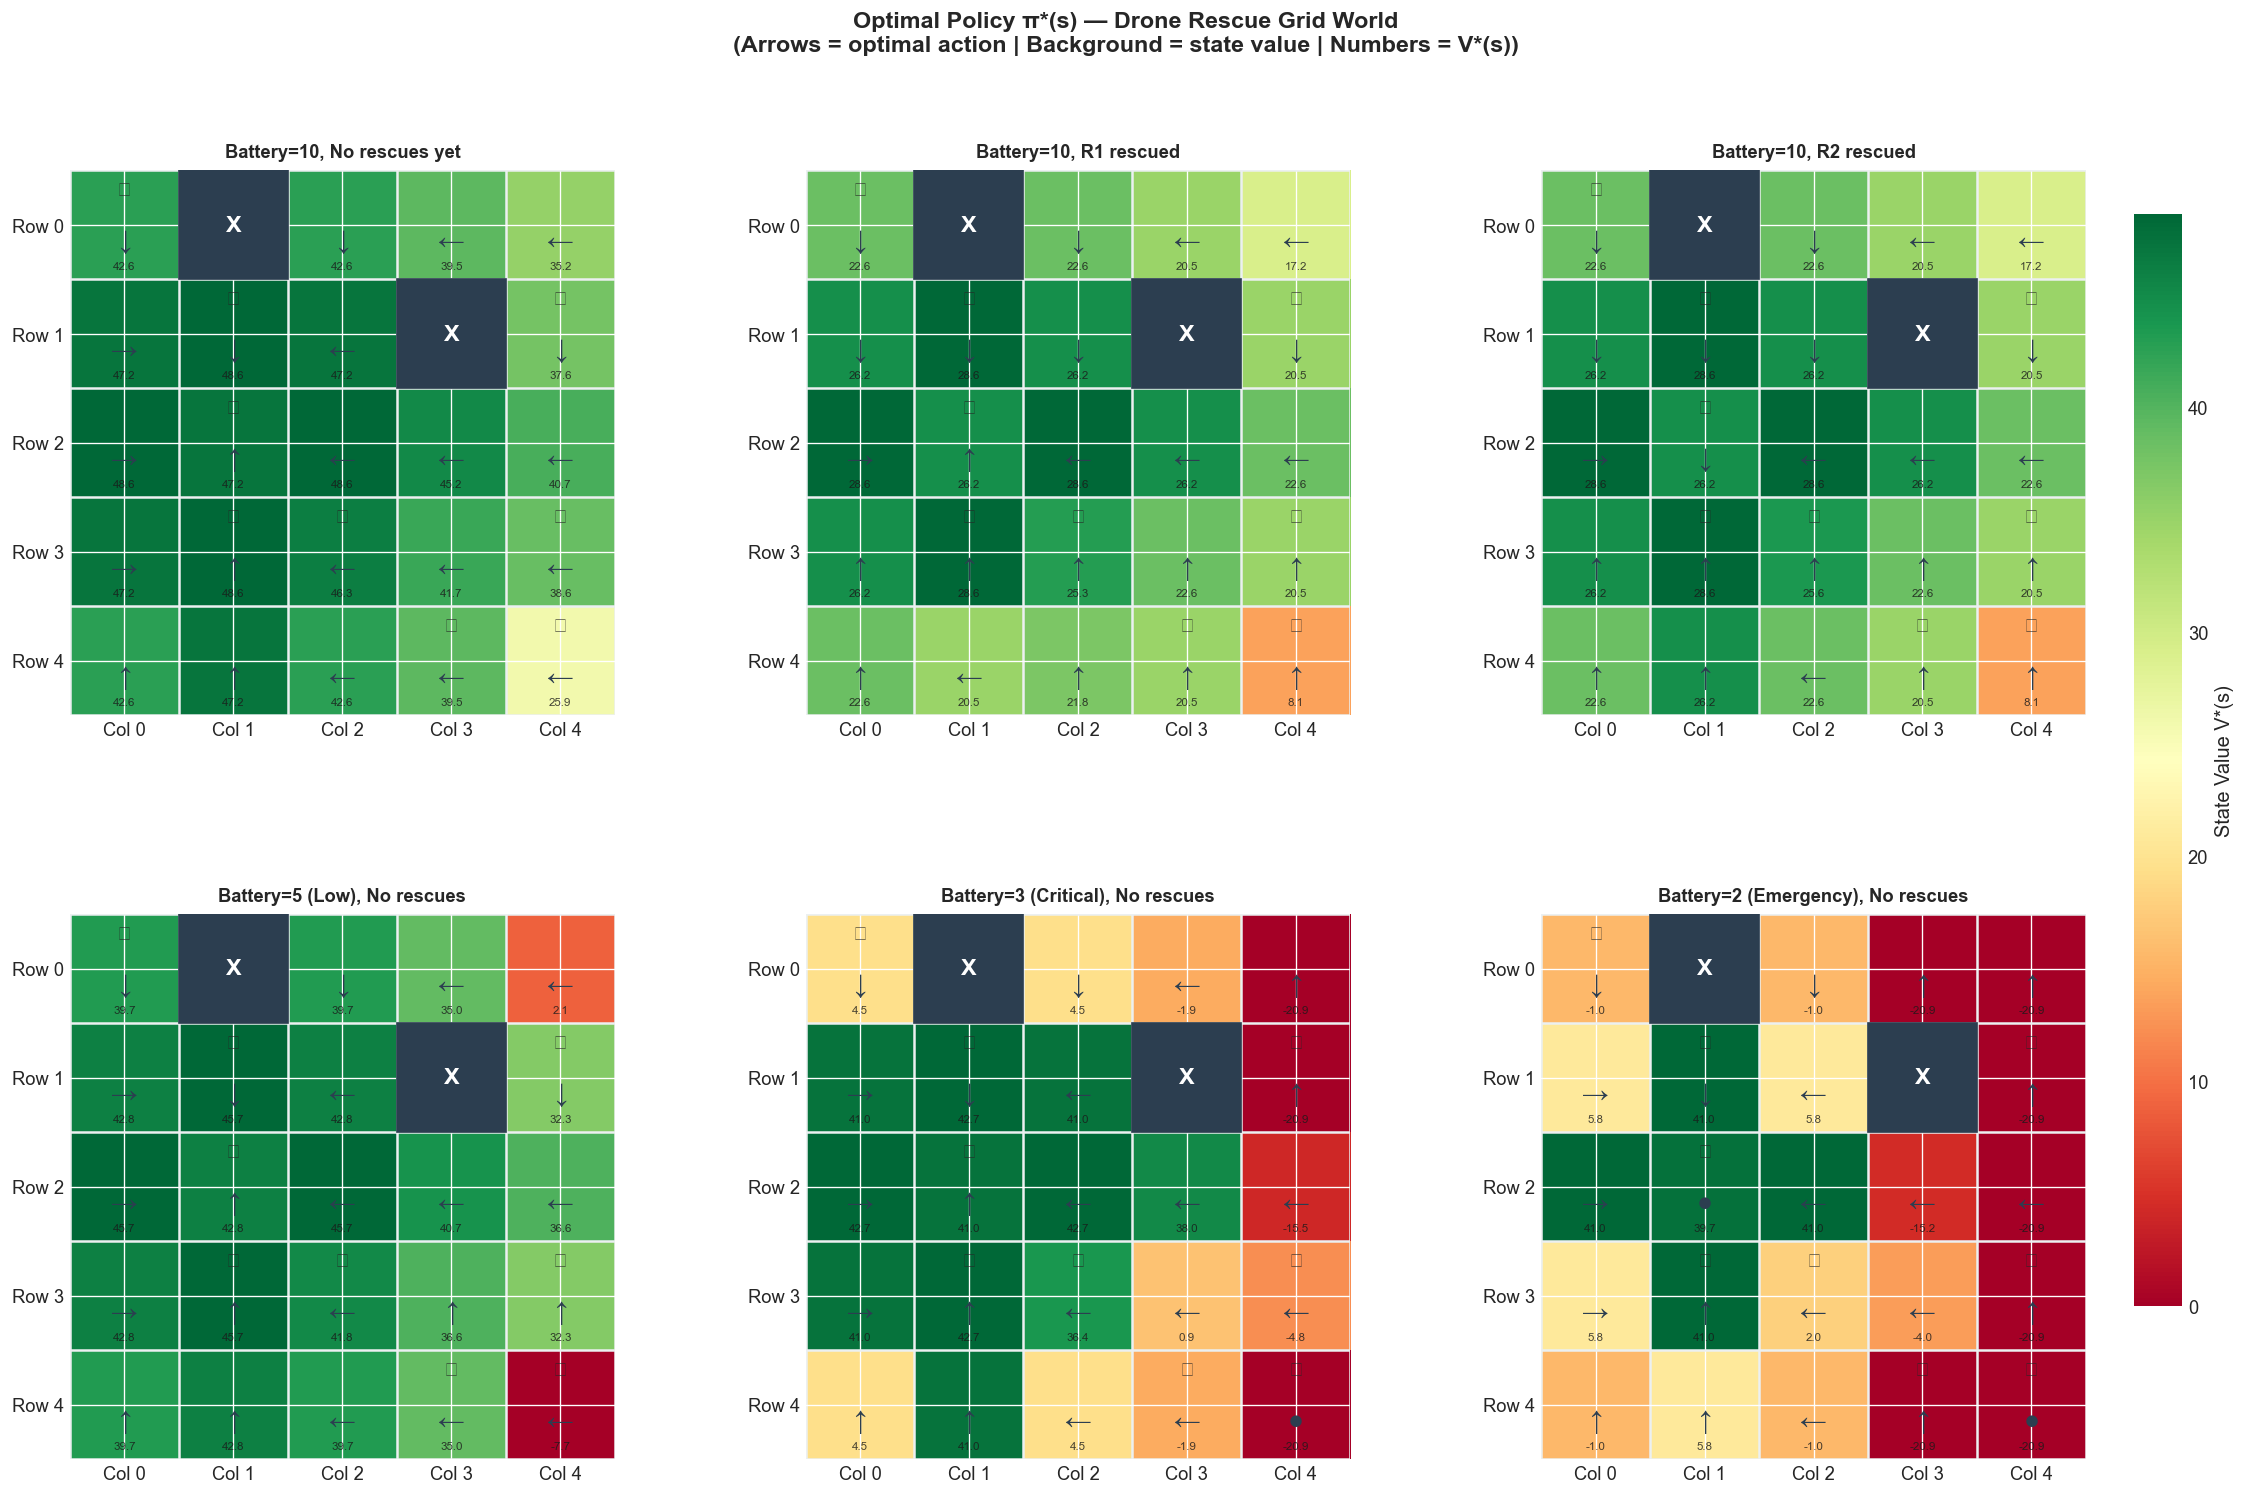

📊 Policy visualization saved.


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 3 — Policy Visualization
# PURPOSE: Visualize the optimal policy as a grid of directional arrows.
#          Show policy slices at different battery levels and target states.
# ─────────────────────────────────────────────────────────────

def visualize_policy(
    V: Dict, policy: Dict,
    battery_level: int,
    t1: int, t2: int,
    ax=None, title: str = ""
):
    """
    Visualize the optimal policy and state values as a grid.

    Parameters
    ----------
    V : dict
        Optimal value function.
    policy : dict
        Optimal policy mapping state → action.
    battery_level : int
        Battery level to visualize.
    t1, t2 : int
        Target rescue status (0=not rescued, 1=rescued).
    ax : matplotlib Axes
        Axes to draw on (creates new figure if None).
    title : str
        Plot title.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # ── Extract V-values for this slice ──────────────────────
    V_grid = np.full((GRID_ROWS, GRID_COLS), np.nan)
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            state = (r, c, battery_level, t1, t2)
            if state in V:
                V_grid[r, c] = V[state]

    # ── Background: Value Heatmap ─────────────────────────────
    # Masked array to handle NaN (blocked/unreachable cells)
    masked_V = np.ma.masked_invalid(V_grid)
    cmap = plt.cm.RdYlGn
    im = ax.imshow(masked_V, cmap=cmap, aspect='equal', origin='upper',
                   vmin=np.nanmin(V_grid), vmax=np.nanmax(V_grid))

    # ── Arrow Map ─────────────────────────────────────────────
    ARROW = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: '●'}
    ARROW_DX = {0: 0, 1: 0, 2: -0.35, 3: 0.35, 4: 0}   # x offset for arrow head
    ARROW_DY = {0: -0.35, 1: 0.35, 2: 0, 3: 0, 4: 0}

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cell = GRID_MAP.get((r, c), CELL_SAFE)

            # ── Cell Label (cell type overlays) ───────────────
            if cell == CELL_BLOCKED:
                ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                                           color='#2c3e50', zorder=2))
                ax.text(c, r, 'X', ha='center', va='center',
                        fontsize=14, color='white', fontweight='bold', zorder=3)
                continue

            # Draw cell labels
            cell_labels = {
                CELL_RESCUE: ('🎯', '#27ae60'),
                CELL_CHARGER: ('⚡', '#f39c12'),
                CELL_DANGER: ('💥', '#c0392b'),
                CELL_WIND: ('🌀', '#8e44ad'),
                CELL_START: ('🏠', '#2980b9'),
            }
            if cell in cell_labels:
                emoji, color = cell_labels[cell]
                ax.text(c, r - 0.32, emoji, ha='center', va='center',
                        fontsize=12, zorder=3)

            # ── Policy Arrow ──────────────────────────────────
            state = (r, c, battery_level, t1, t2)
            if state in policy:
                act = policy[state]
                ax.text(c, r + 0.15, ARROW[act], ha='center', va='center',
                        fontsize=16, color='#2c3e50', fontweight='bold', zorder=4)

            # ── V-value label ─────────────────────────────────
            if state in V and not np.isnan(V.get(state, np.nan)):
                ax.text(c, r + 0.38, f'{V[state]:.1f}',
                        ha='center', va='center', fontsize=7,
                        color='#1a1a1a', alpha=0.8, zorder=4)

    # ── Grid Lines ────────────────────────────────────────────
    ax.set_xticks(np.arange(-0.5, GRID_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_ROWS, 1), minor=True)
    ax.grid(which='minor', color='#ecf0f1', linewidth=1.5)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_xticklabels([f'Col {i}' for i in range(GRID_COLS)])
    ax.set_yticklabels([f'Row {i}' for i in range(GRID_ROWS)])
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    return im


# ── Multi-panel policy visualization ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle(
    'Optimal Policy π*(s) — Drone Rescue Grid World\n'
    '(Arrows = optimal action | Background = state value | Numbers = V*(s))',
    fontsize=14, fontweight='bold'
)

configs = [
    (10, 0, 0, 'Battery=10, No rescues yet'),
    (10, 1, 0, 'Battery=10, R1 rescued'),
    (10, 0, 1, 'Battery=10, R2 rescued'),
    (5,  0, 0, 'Battery=5 (Low), No rescues'),
    (3,  0, 0, 'Battery=3 (Critical), No rescues'),
    (2,  0, 0, 'Battery=2 (Emergency), No rescues'),
]

ims = []
for ax, (bat, t1, t2, title) in zip(axes.flat, configs):
    im = visualize_policy(V_star, pi_star, bat, t1, t2, ax=ax, title=title)
    ims.append(im)

# Add a shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(ims[0], cax=cbar_ax)
cb.set_label('State Value V*(s)', fontsize=12)

plt.subplots_adjust(left=0.06, right=0.90, top=0.88, bottom=0.05,
                    wspace=0.35, hspace=0.35)
plt.savefig('plots/dp_policy_grid.png', bbox_inches='tight', dpi=150)
plt.show()
print("📊 Policy visualization saved.")


## 🌡️ Task 4: State-Value Analysis (V* Heatmap)

### What does V*(s) tell us?

$V^*(s)$ represents the **maximum expected cumulative discounted reward** the drone can achieve starting from state $s$, following the optimal policy.

A high $V^*(s)$ means: *"Starting here, the drone will perform very well."*  
A low (negative) $V^*(s)$ means: *"Starting here is risky — low battery, bad position, etc."*

We plot heatmaps of $V^*(s)$ across all grid positions $(r,c)$ at fixed battery and target status slices.


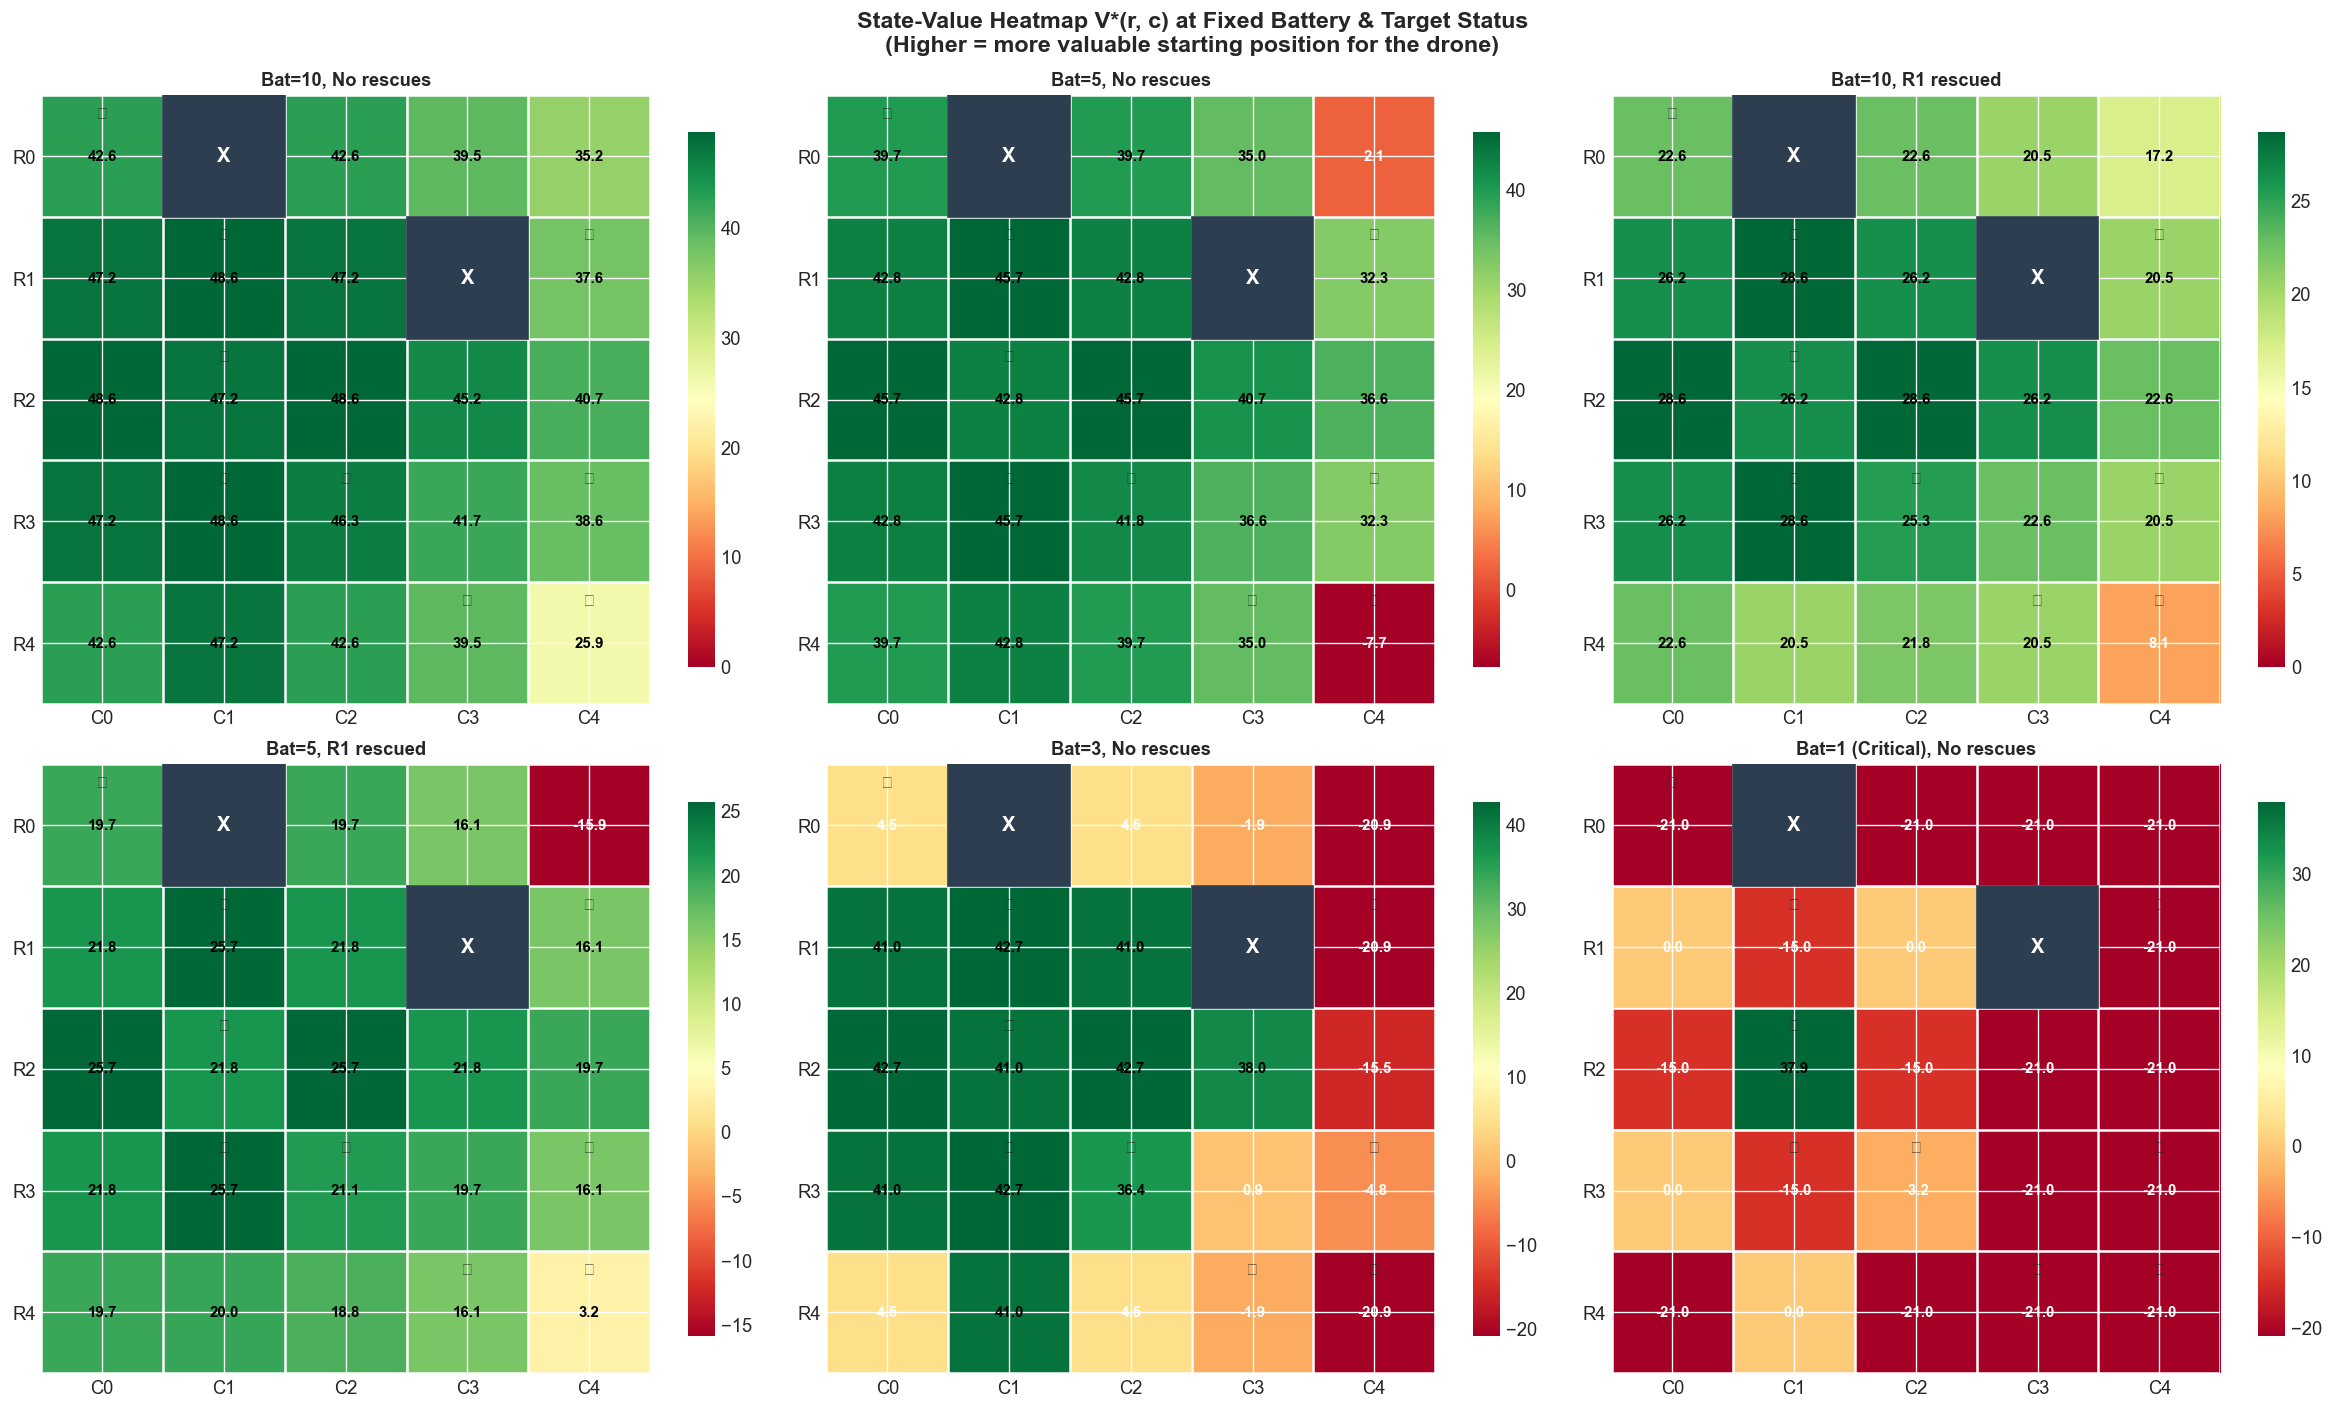

📊 State-Value Heatmap saved.


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 4 — State-Value Heatmap Analysis
# ─────────────────────────────────────────────────────────────
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'State-Value Heatmap V*(r, c) at Fixed Battery & Target Status\n'
    '(Higher = more valuable starting position for the drone)',
    fontsize=14, fontweight='bold'
)

battery_slices = [10, 7, 5, 3, 1]
target_configs = [
    (0, 0, 'No Rescues (t1=0, t2=0)'),
    (1, 0, 'R1 Rescued (t1=1, t2=0)'),
    (0, 1, 'R2 Rescued (t1=0, t2=1)'),
]

bat_levels = [10, 5, 10, 5, 3, 1]
tgt_configs = [(0,0),(0,0),(1,0),(1,0),(0,0),(0,0)]

titles_combined = [
    'Bat=10, No rescues',
    'Bat=5, No rescues',
    'Bat=10, R1 rescued',
    'Bat=5, R1 rescued',
    'Bat=3, No rescues',
    'Bat=1 (Critical), No rescues',
]

for ax, bat, (t1, t2), title in zip(axes.flat, bat_levels, tgt_configs, titles_combined):
    V_grid = np.full((GRID_ROWS, GRID_COLS), np.nan)
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            state = (r, c, bat, t1, t2)
            if state in V_star:
                V_grid[r, c] = V_star[state]

    # ── Heatmap ───────────────────────────────────────────────
    masked = np.ma.masked_invalid(V_grid)
    vmin, vmax = np.nanmin(V_grid), np.nanmax(V_grid)
    im = ax.imshow(masked, cmap='RdYlGn', aspect='equal', origin='upper',
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.8)

    # ── Overlay value numbers ─────────────────────────────────
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cell = GRID_MAP.get((r, c), CELL_SAFE)
            if cell == CELL_BLOCKED:
                ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                                           color='#2c3e50', zorder=2))
                ax.text(c, r, 'X', ha='center', va='center',
                        fontsize=12, color='white', fontweight='bold', zorder=3)
                continue

            if not np.isnan(V_grid[r, c]):
                txt_color = 'white' if V_grid[r, c] < (vmin + (vmax-vmin)*0.4) else 'black'
                ax.text(c, r, f'{V_grid[r,c]:.1f}',
                        ha='center', va='center', fontsize=9,
                        color=txt_color, fontweight='bold', zorder=3)

            # Cell type annotations
            cell_symbols = {
                CELL_RESCUE: '🎯', CELL_CHARGER: '⚡',
                CELL_DANGER: '💥', CELL_WIND: '🌀', CELL_START: '🏠'
            }
            if cell in cell_symbols:
                ax.text(c, r - 0.35, cell_symbols[cell],
                        ha='center', va='center', fontsize=10, zorder=4)

    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_xticklabels([f'C{i}' for i in range(GRID_COLS)])
    ax.set_yticklabels([f'R{i}' for i in range(GRID_ROWS)])
    ax.set_title(title, fontsize=11, fontweight='bold')

    # Grid lines
    ax.set_xticks(np.arange(-0.5, GRID_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_ROWS, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', size=0)

plt.tight_layout()
plt.savefig('plots/dp_value_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("📊 State-Value Heatmap saved.")


## 📐 Task 5: DP Scalability & Curse of Dimensionality

### The Curse of Dimensionality (Bellman, 1957)

Dynamic Programming (DP) requires iterating over the **entire state space** in each sweep. As environment complexity increases, the state space grows **exponentially** — a phenomenon called the **Curse of Dimensionality**.

#### State Space Growth for the Drone Problem:

| Scale | Grid | Targets | Battery | Wind Directions | State Count |
|-------|------|---------|---------|-----------------|-------------|
| Assignment (ours) | 5×5 | 2 | 10 | Static | **1,100** |
| Medium | 6×6 | 3 | 15 | Static | **6,048** |
| City Block | 100×100 | 10 | 100 | 4 dirs | **4 × 10¹⁰** |
| Real Drone | Continuous | Many | Continuous | ∞ | **∞** |

#### Why DP Fails at Scale:

1. **Memory:** Storing $V(s)$ for $4 \times 10^{10}$ states requires terabytes of RAM.
2. **Computation:** Each Value Iteration sweep processes all states × all actions × all next states — quadratic to cubic complexity in the number of states.
3. **Model Requirement:** DP requires knowing $\mathcal{P}(s'\mid s, a)$ exactly — a complete, accurate world model. In real-world robotics, this is impossible to specify.

#### How Deep RL Overcomes This:

Instead of a tabular $V(s)$ (one float per state), Deep RL uses a **neural network** $V_\theta(s)$ to *generalize* across states:

$$V_\theta(s) \approx V^*(s) \quad \forall s \in \mathcal{S}$$

Key Deep RL approaches:

| Method | Key Idea | Applicable To |
|--------|----------|---------------|
| **DQN** (Mnih et al., 2015) | CNN approximates Q*(s,a) | Discrete actions, high-dim obs |
| **PPO** (Schulman et al., 2017) | Policy gradient with clipped surrogate | Continuous action spaces |
| **SAC** (Haarnoja et al., 2018) | Off-policy, entropy-regularized | Robotic control |
| **MuZero** (Schrittwieser et al., 2020) | Learned world model + MCTS | Complex planning (Chess, Go, Atari) |

**The key trade-off:**
- DP: **Exact, guaranteed convergence** — but requires complete model and small state space.
- Deep RL: **Approximate, no convergence guarantees** — but scales to continuous, high-dimensional, real-world problems.


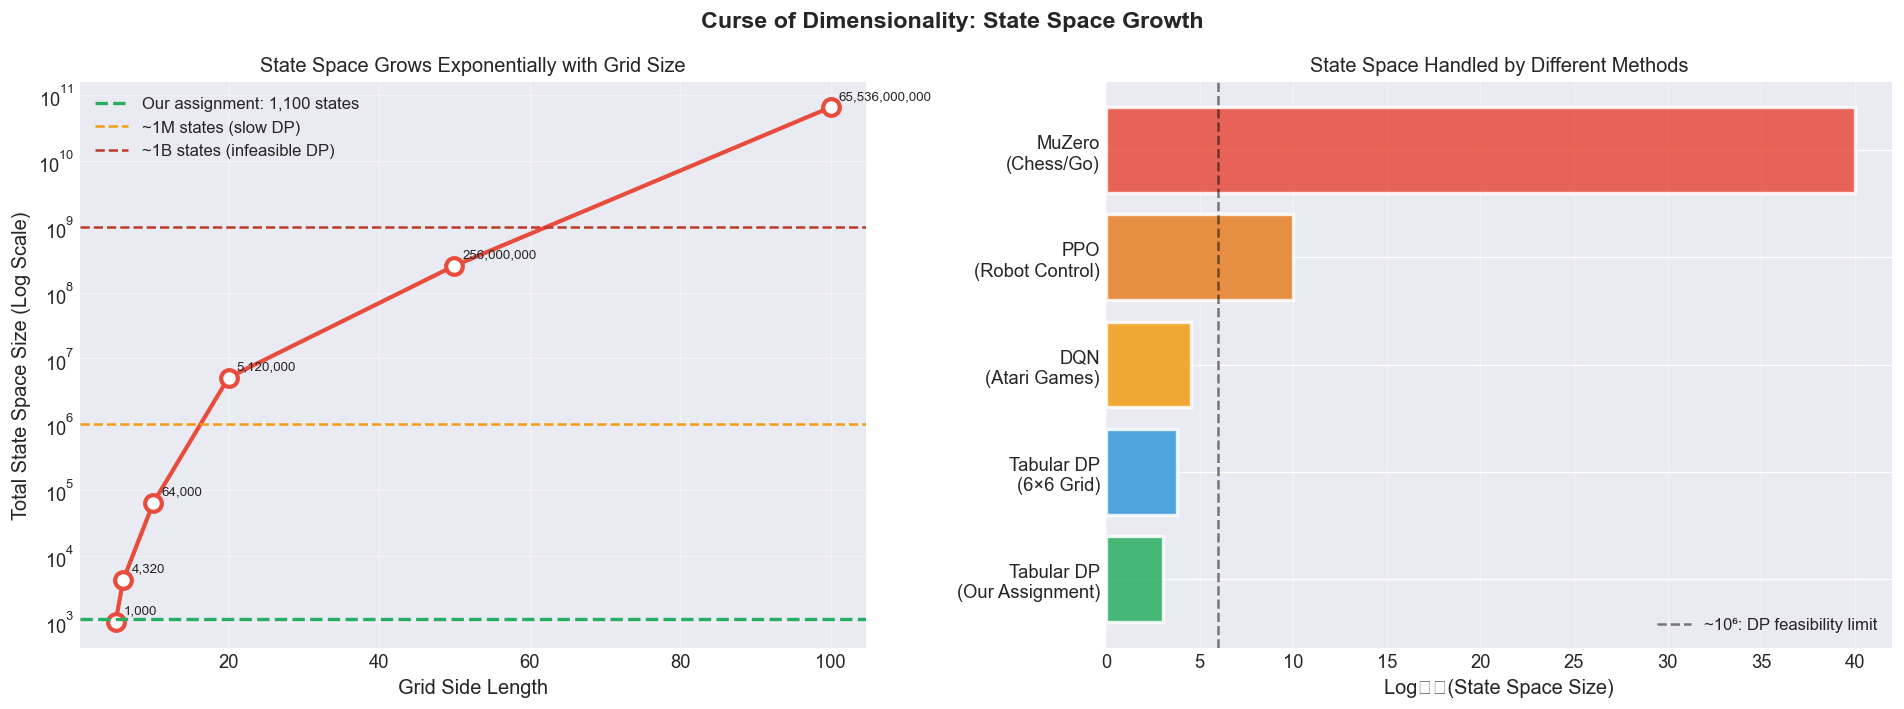

📊 Curse of Dimensionality plot saved.


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 5 — Curse of Dimensionality Visualization
# ─────────────────────────────────────────────────────────────

# State space size as environment parameters scale
grid_sizes   = [5,   6,   10,   20,   50,   100]
n_grids      = [g*g for g in grid_sizes]
n_batteries  = [10,  15,  20,   50,   100,  200]
n_targets_2  = [2**2, 2**3, 2**5, 2**8, 2**10, 2**15]   # 2^K for K targets

state_counts = [g * b * t for g, b, t in zip(n_grids, n_batteries, n_targets_2)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Curse of Dimensionality: State Space Growth', fontsize=14, fontweight='bold')

# Plot 1: State space vs grid size
ax1.semilogy(grid_sizes, state_counts, 'o-', color='#e74c3c', linewidth=2.5,
             markersize=10, markerfacecolor='white', markeredgewidth=2.5)
ax1.axhline(1100, color='#27ae60', linestyle='--', linewidth=2,
            label=f'Our assignment: {1100:,} states')
ax1.axhline(1e6,  color='#f39c12', linestyle='--', linewidth=1.5,
            label='~1M states (slow DP)')
ax1.axhline(1e9,  color='#c0392b', linestyle='--', linewidth=1.5,
            label='~1B states (infeasible DP)')
ax1.set_xlabel('Grid Side Length', fontsize=12)
ax1.set_ylabel('Total State Space Size (Log Scale)', fontsize=12)
ax1.set_title('State Space Grows Exponentially with Grid Size', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.4)

for x, y, label in zip(grid_sizes, state_counts, [f'{v:,.0f}' for v in state_counts]):
    ax1.annotate(label, (x, y), textcoords='offset points', xytext=(5, 5), fontsize=8)

# Plot 2: DP vs Deep RL scalability comparison
ax2.barh(['Tabular DP\n(Our Assignment)', 'Tabular DP\n(6×6 Grid)', 'DQN\n(Atari Games)',
          'PPO\n(Robot Control)', 'MuZero\n(Chess/Go)'],
         [np.log10(1100), np.log10(6048), np.log10(33600), np.log10(1e10), np.log10(1e40)],
         color=['#27ae60', '#3498db', '#f39c12', '#e67e22', '#e74c3c'],
         alpha=0.85, edgecolor='white', linewidth=2)

ax2.set_xlabel('Log₁₀(State Space Size)', fontsize=12)
ax2.set_title('State Space Handled by Different Methods', fontsize=12)
ax2.axvline(6, color='black', linestyle='--', linewidth=1.5, alpha=0.5,
            label='~10⁶: DP feasibility limit')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig('plots/dp_curse_of_dimensionality.png', bbox_inches='tight', dpi=150)
plt.show()
print("📊 Curse of Dimensionality plot saved.")


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL: Final Summary
# ─────────────────────────────────────────────────────────────

print("=" * 70)
print("  PART 2 COMPLETE — DYNAMIC PROGRAMMING SUMMARY")
print("=" * 70)
print(f"  Group       : 84  |  Env Seed Student ID: 2025aa05368 (Alphabetically First)")
print(f"  All Members : 2025aa05368, 2025aa05574, 2025aa05710, 2025ab05154, 2025ab05256")
print(f"  Grid        : {GRID_ROWS}×{GRID_COLS}  |  Battery: {MAX_BATTERY}  |  Wind: {WIND_PROB*100:.0f}%")
print()
print(f"  Value Iteration Results:")
print(f"    Converged in : {len(convergence_deltas)} iterations")
print(f"    Final Δ      : {convergence_deltas[-1]:.2e}")
print(f"    γ (discount) : {GAMMA}")
print()

# Show sample optimal values
sample_states = [
    (0, 0, 10, 0, 0, "Start, full battery, no rescues"),
    (1, 2, 10, 0, 0, "At R1 target, full battery"),
    (4, 0, 10, 0, 0, "At R2 target, full battery"),
    (2, 1, 10, 0, 0, "At charger, full battery"),
    (2, 2, 10, 0, 0, "At danger zone, full battery"),
    (0, 0,  2, 0, 0, "Start, critical battery"),
]

print(f"  Sample State Values:")
print(f"    {'State':<45} {'V*(s)':>8} {'π*(s)':>10}")
print("    " + "-" * 65)
for r, c, b, t1, t2, desc in sample_states:
    state = (r, c, b, t1, t2)
    val    = V_star.get(state, float('nan'))
    action = pi_star.get(state, -1)
    act_name = ACTION_NAMES.get(action, '?')
    print(f"    {desc:<45} {val:>8.2f} {act_name:>10}")

print()
print("  Key Observations:")
print("    1. Higher battery → Higher V* (more options available)")
print("    2. At rescue targets: V* is high (mission progress)")
print("    3. At danger zones: V* is lower (penalty risk)")
print("    4. Critical battery states have very low V* → policy forces charging")
print("    5. Value Iteration guarantees convergence via Bellman contraction")
print("=" * 70)


  PART 2 COMPLETE — DYNAMIC PROGRAMMING SUMMARY
  Group       : 84  |  Env Seed Student ID: 2025aa05368 (Alphabetically First)
  All Members : 2025aa05368, 2025aa05574, 2025aa05710, 2025ab05154, 2025ab05256
  Grid        : 5×5  |  Battery: 10  |  Wind: 20%

  Value Iteration Results:
    Converged in : 7 iterations
    Final Δ      : 2.10e-04
    γ (discount) : 0.95

  Sample State Values:
    State                                            V*(s)      π*(s)
    -----------------------------------------------------------------
    Start, full battery, no rescues                  42.60      Down↓
    At R1 target, full battery                       47.21      Left←
    At R2 target, full battery                       42.60        Up↑
    At charger, full battery                         47.21        Up↑
    At danger zone, full battery                     48.60      Left←
    Start, critical battery                          -1.00      Down↓

  Key Observations:
    1. Higher battery → Hi